In [1]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [2]:
def generate_graph(n, m):
    return nx.gnm_random_graph(n, m)

In [3]:
def coloring_conflicts(G, coloring):
    conflicts = 0
    for u, v in G.edges():
        if coloring[u] == coloring[v]:
            conflicts += 1
    return conflicts

In [4]:
def random_coloring(G, num_colors):
    coloring = {}
    for node in G.nodes():
        coloring[node] = random.randint(0, num_colors-1)
    return coloring

In [5]:
def chromatic_optimiser_neighbourhood(G, coloring, num_colors, hops=1, max_passes=10, max_nodes=4):
    for _ in range(max_passes):
        changed = False

        nodes = list(G.nodes())
        random.shuffle(nodes)

        for node in nodes:
            ego = nx.ego_graph(G, node, radius=hops)
            nodes_in_ego = list(ego.nodes())
            nodes_to_optimize = [n for n in nodes_in_ego if n != node]

            # Limit combinatorial explosion
            if len(nodes_to_optimize) > max_nodes:
                nodes_to_optimize = random.sample(nodes_to_optimize, max_nodes)

            best_conflicts = float('inf')
            best_assignment = None

            for assignment in itertools.product(range(num_colors), repeat=len(nodes_to_optimize)):
                for i, n in enumerate(nodes_to_optimize):
                    coloring[n] = assignment[i]

                conflicts = 0
                for u, v in ego.edges():
                    if coloring[u] == coloring[v]:
                        conflicts += 1

                if conflicts < best_conflicts:
                    best_conflicts = conflicts
                    best_assignment = assignment
                    if best_conflicts == 0:
                        break

            if best_assignment is not None:
                for i, n in enumerate(nodes_to_optimize):
                    if coloring[n] != best_assignment[i]:
                        coloring[n] = best_assignment[i]
                        changed = True

        if not changed:
            break

    return coloring

In [6]:
def run_trials(hops_values, n, m):
    initial_results = {h: [] for h in hops_values}
    optimised_results = {h: [] for h in hops_values}
    reduction_results = {h: [] for h in hops_values}

    for _ in range(num_trials):
        G = generate_graph(n, m)
        coloring = random_coloring(G, num_colors)
        initial_conflicts = coloring_conflicts(G, coloring)

        for hops in hops_values:
            test_coloring = coloring.copy()
            optimised_coloring = chromatic_optimiser_neighbourhood(G, test_coloring, num_colors, hops)
            optimised_conflicts = coloring_conflicts(G, optimised_coloring)
            reduction = initial_conflicts - optimised_conflicts

            initial_results[hops].append(initial_conflicts)
            optimised_results[hops].append(optimised_conflicts)
            reduction_results[hops].append(reduction)

    return initial_results, optimised_results, reduction_results

# Experiment 1

In [7]:
num_trials = 5
n = 80
m = 190
num_colors = 4

In [8]:
hops_values = [1, 2, 3]

In [9]:
initial_results, optimised_results, reduction_results = run_trials(hops_values, n, m)

# Compute averages and standard deviations
avg_initial = [np.mean(initial_results[h]) for h in hops_values]
avg_optimised = [np.mean(optimised_results[h]) for h in hops_values]
avg_reductions = [np.mean(reduction_results[h]) for h in hops_values]

std_initial = [np.std(initial_results[h]) for h in hops_values]
std_optimised = [np.std(optimised_results[h]) for h in hops_values]
std_reductions = [np.std(reduction_results[h]) for h in hops_values]

[np.float64(57.2), np.float64(33.2), np.float64(6.2)]
[np.float64(5.775811631277461), np.float64(4.791659420284375), np.float64(2.785677655436824)]


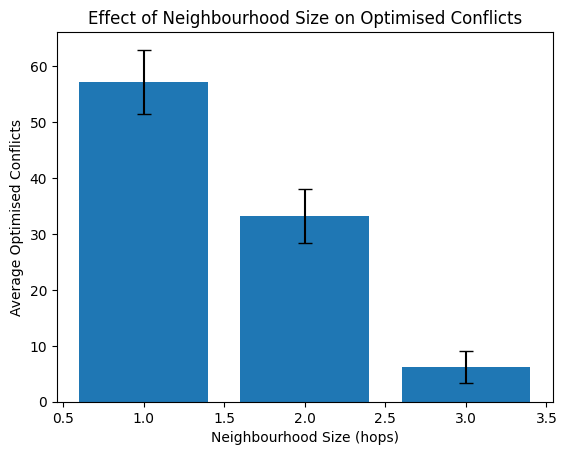

In [10]:
plt.bar(hops_values, avg_optimised, yerr=std_optimised, capsize=5)

print(avg_optimised)
print(std_optimised)

plt.xlabel("Neighbourhood Size (hops)")
plt.ylabel("Average Optimised Conflicts")
plt.title("Effect of Neighbourhood Size on Optimised Conflicts")

plt.show()

[np.float64(-9.0), np.float64(15.0), np.float64(42.0)]
[np.float64(2.449489742783178), np.float64(5.019960159204453), np.float64(5.329165037789691)]


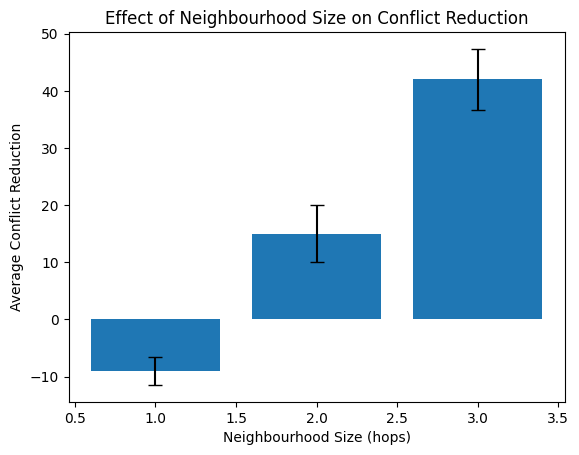

In [11]:
plt.bar(hops_values, avg_reductions, yerr=std_reductions, capsize=5)

print(avg_reductions)
print(std_reductions)
plt.xlabel("Neighbourhood Size (hops)")
plt.ylabel("Average Conflict Reduction")
plt.title("Effect of Neighbourhood Size on Conflict Reduction")

plt.show()

# Experiment 2
Examine the affect of graph density with neighbourhood size

In [12]:
densities = [20, 40, 60, 80, 100, 120, 140]
hops_values = [3]
n = 30

density_results = {}

for m in densities:

    initial_results, optimised_results, reduction_results = run_trials(hops_values, n, m)

    avg_initial = [np.mean(initial_results[h]) for h in hops_values]
    avg_optimised = [np.mean(optimised_results[h]) for h in hops_values]
    avg_reductions = [np.mean(reduction_results[h]) for h in hops_values]

    initial_results, optimised_results, reduction_results = run_trials(hops_values, n, m)

    density_results[m] = {
        'avg_initial': np.mean(initial_results[3]),
        'avg_optimised': np.mean(optimised_results[3]),
        'avg_reductions': np.mean(reduction_results[3]),
        'initial_all': initial_results[3],
        'optimised_all': optimised_results[3],
        'reduction_all': reduction_results[3]
    }

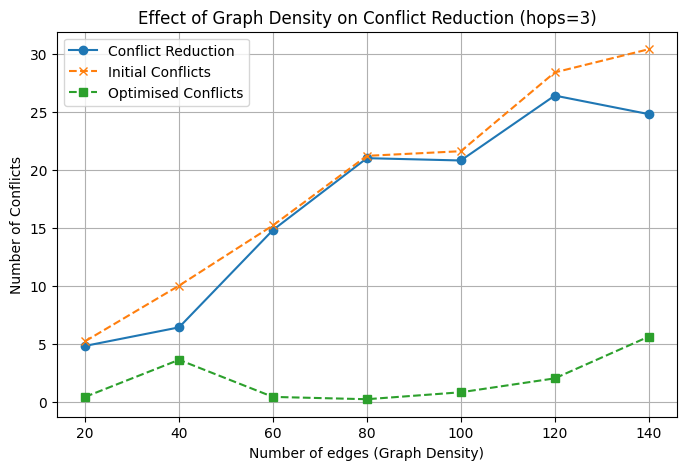

In [13]:
densities = list(density_results.keys())

# Extract averages
avg_initial = [density_results[m]['avg_initial'] for m in densities]
avg_optimised = [density_results[m]['avg_optimised'] for m in densities]
avg_reductions = [density_results[m]['avg_reductions'] for m in densities]

plt.figure(figsize=(8,5))
plt.plot(densities, avg_reductions, marker='o', linestyle='-', label='Conflict Reduction')
plt.plot(densities, avg_initial, marker='x', linestyle='--', label='Initial Conflicts')
plt.plot(densities, avg_optimised, marker='s', linestyle='--', label='Optimised Conflicts')

plt.xlabel("Number of edges (Graph Density)")
plt.ylabel("Number of Conflicts")
plt.title("Effect of Graph Density on Conflict Reduction (hops=3)")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
densities = [20, 40, 60, 80, 100, 120, 140]
hops_values = [1]
n = 30

density_results = {}

for m in densities:

    initial_results, optimised_results, reduction_results = run_trials(hops_values, n, m)

    avg_initial = [np.mean(initial_results[h]) for h in hops_values]
    avg_optimised = [np.mean(optimised_results[h]) for h in hops_values]
    avg_reductions = [np.mean(reduction_results[h]) for h in hops_values]

    initial_results, optimised_results, reduction_results = run_trials(hops_values, n, m)

    density_results[m] = {
        'avg_initial': np.mean(initial_results[1]),
        'avg_optimised': np.mean(optimised_results[1]),
        'avg_reductions': np.mean(reduction_results[1]),
        'initial_all': initial_results[1],
        'optimised_all': optimised_results[1],
        'reduction_all': reduction_results[1]
    }

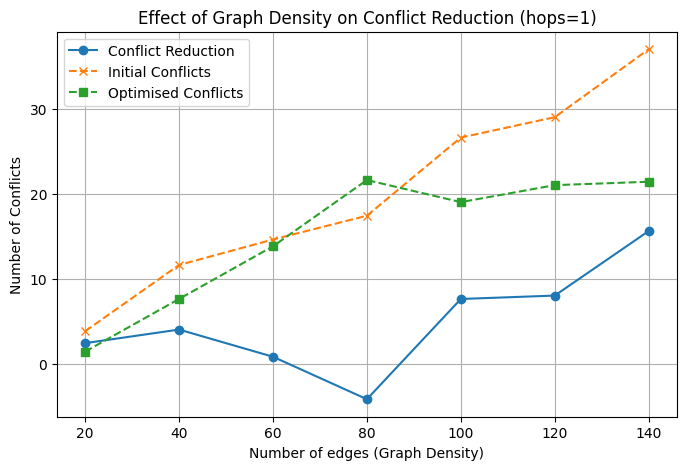

In [15]:
densities = list(density_results.keys())

avg_initial = [density_results[m]['avg_initial'] for m in densities]
avg_optimised = [density_results[m]['avg_optimised'] for m in densities]
avg_reductions = [density_results[m]['avg_reductions'] for m in densities]

plt.figure(figsize=(8,5))
plt.plot(densities, avg_reductions, marker='o', linestyle='-', label='Conflict Reduction')
plt.plot(densities, avg_initial, marker='x', linestyle='--', label='Initial Conflicts')
plt.plot(densities, avg_optimised, marker='s', linestyle='--', label='Optimised Conflicts')

plt.xlabel("Number of edges (Graph Density)")
plt.ylabel("Number of Conflicts")
plt.title("Effect of Graph Density on Conflict Reduction (hops=1)")
plt.legend()
plt.grid(True)
plt.show()

# Experiment 3

In [16]:
num_trials = 5
num_colors = 5
hops_values = [1, 2, 3]
graph_sizes = [20, 30, 50, 80]
density_factor = 2

results_initial = {h: [] for h in hops_values}
results_optimised = {h: [] for h in hops_values}
results_reduction = {h: [] for h in hops_values}

for n in graph_sizes:
    m = n * density_factor

    initial_res, optimised_res, reduction_res = run_trials(hops_values, n, m)

    for hops in hops_values:
        results_initial[hops].append(np.mean(initial_res[hops]))
        results_optimised[hops].append(np.mean(optimised_res[hops]))
        results_reduction[hops].append(np.mean(reduction_res[hops]))

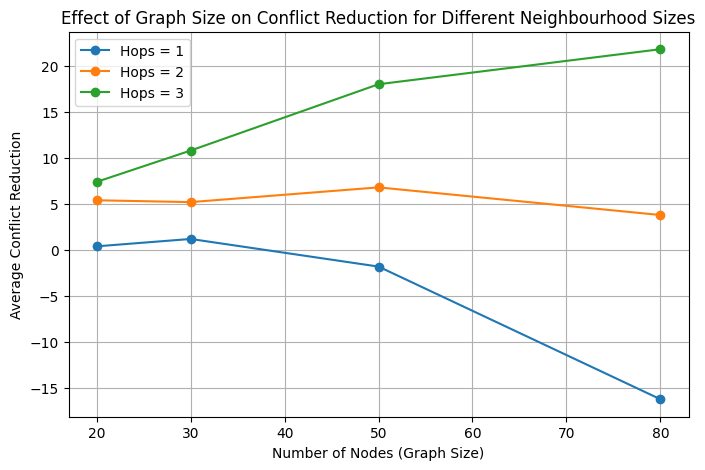

In [17]:
plt.figure(figsize=(8,5))
for hops in hops_values:
    plt.plot(graph_sizes, results_reduction[hops], marker='o', label=f'Hops = {hops}')

plt.xlabel("Number of Nodes (Graph Size)")
plt.ylabel("Average Conflict Reduction")
plt.title("Effect of Graph Size on Conflict Reduction for Different Neighbourhood Sizes")
plt.grid(True)
plt.legend()
plt.show()

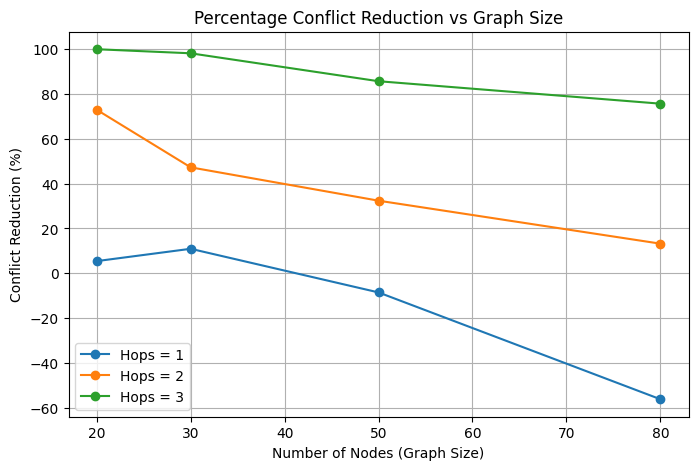

In [18]:
plt.figure(figsize=(8,5))

for hops in hops_values:
    percent_reduction = [
        100 * results_reduction[hops][i] / results_initial[hops][i]
        for i in range(len(graph_sizes))
    ]
    plt.plot(graph_sizes, percent_reduction, marker='o', label=f'Hops = {hops}')

plt.xlabel("Number of Nodes (Graph Size)")
plt.ylabel("Conflict Reduction (%)")
plt.title("Percentage Conflict Reduction vs Graph Size")
plt.grid(True)
plt.legend()
plt.show()